# The Carbon Footprint of Meat Demand
### An animal-protein supply-chain sustainability analysis

**Question:** Not just *how much* meat the world eats, but what the changing *mix* of meat means for greenhouse-gas emissions — and where the biggest, most practical levers for a lower-carbon animal supply chain lie.

**TL;DR (from the analysis below):**
- In 2020, **beef was ~21% of meat volume but ~68% of the meat carbon footprint** — the *mix* matters more than the total.
- World per-capita meat is **roughly flat**; the real change is the **shift toward poultry**, which is ~10× less carbon-intense per kg than beef.
- Clustering countries by their meat mix reveals **diet archetypes** ranging from ~27 to ~59 kg CO₂e per kg of meat eaten.
- A naive "same as last year" baseline **beats a linear-trend forecast** for these smooth series — a reminder to always benchmark models.
- **Shifting 25% of world beef volume to poultry** would cut the estimated meat footprint by **~15%**.


## Background & why this fits a real supply-chain problem
Animal-based food systems are a major source of agricultural greenhouse gases (largely methane from enteric fermentation and manure, and nitrous oxide from feed/fertiliser). For anyone advising on **supply-chain sustainability**, the actionable question isn't only total demand — it's the **composition** of that demand, because emission intensity varies enormously between products. This notebook builds a transparent, country-level **emissions-footprint metric** for meat demand and uses it to surface trends, segment countries, sanity-check a forecast, and quantify one practical lever.

## Data & methods
**Sources**
- **OECD–FAO Agricultural Outlook — meat data** (`data/oecd_meat.csv`): consumption by country, year (1990–2028, incl. projections) and meat type (beef, pig, poultry, sheep), in kg/capita and thousand tonnes.
- **Our World in Data — CO₂ & GHG** (`data/owid_emissions_subset.csv`): national methane, nitrous oxide, population (used for an independent cross-check).

**Emission factors** — mean life-cycle GHG per kg of product, from **Poore & Nemecek (2018, *Science*)** via Our World in Data:

| Product | kg CO₂e per kg |
|---|---|
| Beef (beef herd) | 99.5 |
| Lamb & mutton (sheep) | 39.7 |
| Pig meat | 12.3 |
| Poultry meat | 9.9 |

> **Important caveat (stated up front):** these are *global meta-analysis means*. Real intensity varies widely with production system, feed, and region — which is precisely the kind of variation a consultancy like FAI exists to measure. Layering single factors gives a defensible **first-order** estimate for comparing the *mix*, not a precise per-country inventory. Limitations are discussed at the end.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110

TYPES = ["BEEF","PIG","POULTRY","SHEEP"]
# Poore & Nemecek (2018) mean GHG, kg CO2e per kg product (via Our World in Data)
EF = {"BEEF":99.48, "SHEEP":39.72, "PIG":12.31, "POULTRY":9.87}

### Load & clean
The meat file is a long/tidy table (one row per location-type-measure-year). We pivot it to a wide format per measure, and standardise column names. We keep both the per-capita (`KG_CAP`) and total-volume (`THND_TONNE`) views, and separate true countries from aggregate regions (`WLD`, `OECD`, `BRICS`, `EU27`) so they aren't mixed into the country-level clustering.

In [2]:
m = pd.read_csv("data/oecd_meat.csv"); m.columns = [x.strip().strip("\ufeff") for x in m.columns]
m = m[["LOCATION","SUBJECT","MEASURE","TIME","Value"]].dropna()
AGG = {"WLD","OECD","BRICS","EU27","EU28","NONOECD","EU"}

kcap = m[m.MEASURE=="KG_CAP"].pivot_table(index=["LOCATION","TIME"], columns="SUBJECT", values="Value").reset_index()
tonn = m[m.MEASURE=="THND_TONNE"].pivot_table(index=["LOCATION","TIME"], columns="SUBJECT", values="Value").reset_index()
for d in (kcap, tonn):
    for t in TYPES:
        if t not in d: d[t] = np.nan

print("Years:", m.TIME.min(), "-", m.TIME.max(), "| meat types:", sorted(m.SUBJECT.unique()))
print("Locations:", kcap.LOCATION.nunique(), "| per-capita rows:", len(kcap), "| volume rows:", len(tonn))
kcap.head()

Years: 1990 - 2028 | meat types: ['BEEF', 'PIG', 'POULTRY', 'SHEEP']
Locations: 39 | per-capita rows: 1514 | volume rows: 1521


SUBJECT,LOCATION,TIME,BEEF,PIG,POULTRY,SHEEP
0,ARG,1990,55.369995,3.661265,8.630686,0.000003
1,ARG,1991,51.637983,3.599023,8.849335,2.339080
2,ARG,1992,50.789178,4.469865,9.989416,1.886698
3,ARG,1993,51.464667,4.830727,15.378305,1.860911
4,ARG,1994,48.375233,4.814914,18.309126,2.363261


## 1. How meat consumption is changing
The headline trend is not *more* meat per person overall, but a **structural shift toward poultry**.

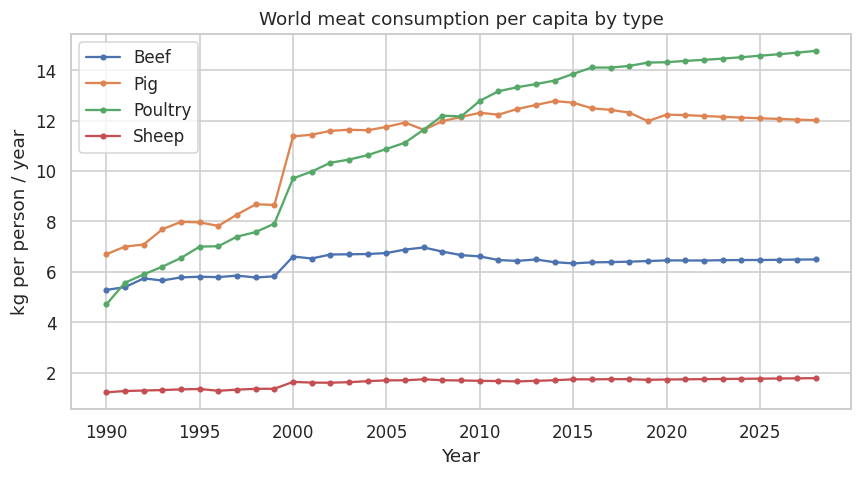

In [3]:
w = kcap[kcap.LOCATION=="WLD"].set_index("TIME")[TYPES]
plt.figure(figsize=(8,4.5))
for t in TYPES: plt.plot(w.index, w[t], marker="o", ms=3, label=t.title())
plt.title("World meat consumption per capita by type"); plt.ylabel("kg per person / year"); plt.xlabel("Year")
plt.legend(); plt.tight_layout(); plt.savefig("figures/01_percapita_by_type.png"); plt.show()

## 2. Volume vs footprint — why the *mix* is the story
We convert volumes to an emissions footprint with the factors above: `footprint = volume × emission factor`. Comparing each product's **share of volume** to its **share of footprint** is the core sustainability insight.

         Share of volume  Share of carbon footprint
Beef                21.4                       68.0
Pig                 36.4                       14.3
Poultry             37.7                       11.9
Sheep                4.6                        5.8


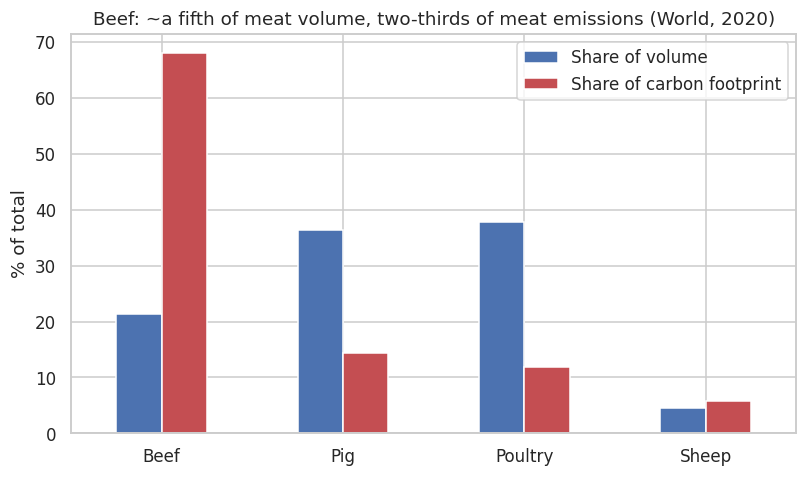

In [4]:
for t in TYPES: tonn[t+"_co2"] = tonn[t]*EF[t]*1e-3            # Mt CO2e (volume is thousand tonnes)
tonn["total_meat_kt"] = tonn[TYPES].sum(axis=1)
tonn["total_co2_Mt"]  = tonn[[t+"_co2" for t in TYPES]].sum(axis=1)

wt = tonn[tonn.LOCATION=="WLD"].sort_values("TIME"); latest = wt[wt.TIME==2020].iloc[0]
comp = pd.DataFrame({"Share of volume":{t: latest[t]/latest.total_meat_kt*100 for t in TYPES},
                     "Share of carbon footprint":{t: latest[t+"_co2"]/latest.total_co2_Mt*100 for t in TYPES}})
comp.index = [i.title() for i in comp.index]
print(comp.round(1).to_string())

ax = comp.plot(kind="bar", figsize=(7.5,4.5), color=["#4c72b0","#c44e52"])
plt.title("Beef: ~a fifth of meat volume, two-thirds of meat emissions (World, 2020)")
plt.ylabel("% of total"); plt.xticks(rotation=0); plt.tight_layout()
plt.savefig("figures/02_volume_vs_footprint.png"); plt.show()

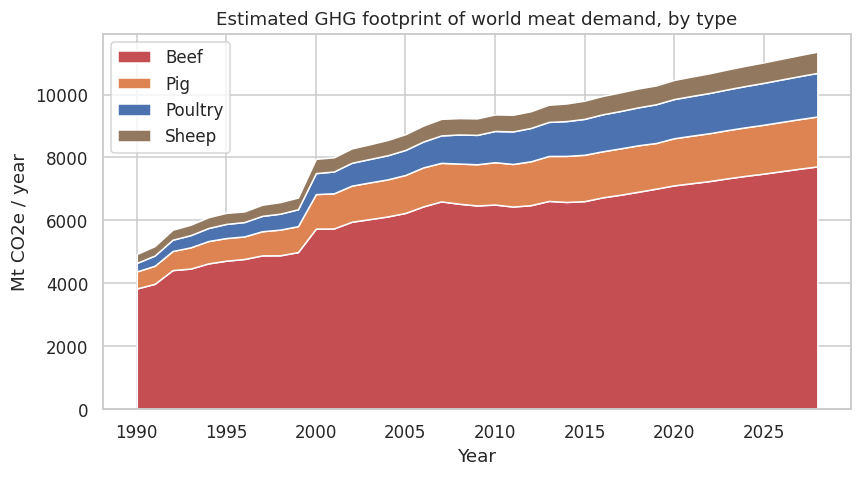

In [5]:
plt.figure(figsize=(8,4.5))
plt.stackplot(wt.TIME, [wt[t+"_co2"] for t in TYPES], labels=[t.title() for t in TYPES],
              colors=["#c44e52","#dd8452","#4c72b0","#937860"])
plt.title("Estimated GHG footprint of world meat demand, by type"); plt.ylabel("Mt CO2e / year"); plt.xlabel("Year")
plt.legend(loc="upper left"); plt.tight_layout(); plt.savefig("figures/03_footprint_over_time.png"); plt.show()

## 3. Meat-diet archetypes (clustering)
Different countries eat very different *mixes*. We cluster countries (k-means, 2018) on the **share** of each meat type in their diet, then look at two intensities: **CO₂e per kg of meat eaten** (isolates the *mix* effect) and **CO₂e per capita** (also reflects how *much* meat is eaten).

In [6]:
ry = 2018
cc = kcap[(~kcap.LOCATION.isin(AGG)) & (kcap.TIME==ry)].dropna(subset=TYPES).copy()
cc["total"] = cc[TYPES].sum(axis=1)
for t in TYPES: cc[t+"_sh"] = cc[t]/cc["total"]
feat = [t+"_sh" for t in TYPES]
cc["cluster"] = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(StandardScaler().fit_transform(cc[feat]))
for t in TYPES: cc[t+"_co2pc"] = cc[t]*EF[t]
cc["co2_pc"] = cc[[t+"_co2pc" for t in TYPES]].sum(axis=1)
cc["co2_per_kg_meat"] = cc["co2_pc"]/cc["total"]

prof = cc.groupby("cluster").agg(n=("LOCATION","size"), beef_sh=("BEEF_sh","mean"), pig_sh=("PIG_sh","mean"),
        poultry_sh=("POULTRY_sh","mean"), sheep_sh=("SHEEP_sh","mean"),
        total_kg=("total","mean"), co2_per_kg=("co2_per_kg_meat","mean"), co2_pc=("co2_pc","mean")
        ).round(2).sort_values("co2_per_kg")
print(prof.to_string())

          n  beef_sh  pig_sh  poultry_sh  sheep_sh  total_kg  co2_per_kg   co2_pc
cluster                                                                          
1         9     0.17    0.04        0.72      0.07     41.61       26.87  1102.66
0         9     0.18    0.49        0.31      0.02     44.45       27.95  1287.74
3        13     0.24    0.22        0.51      0.03     66.22       33.00  2207.16
2         4     0.48    0.08        0.23      0.20     17.51       59.22   932.49


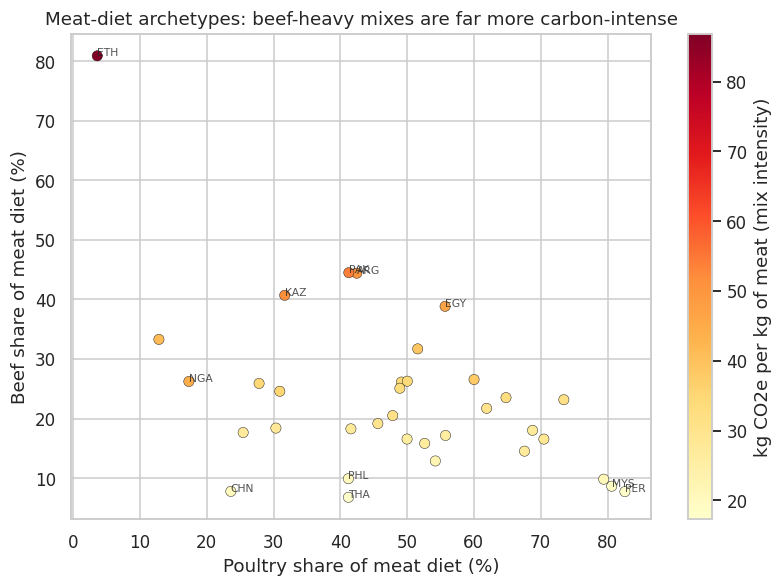

In [7]:
plt.figure(figsize=(7.5,5.5))
sc = plt.scatter(cc.POULTRY_sh*100, cc.BEEF_sh*100, c=cc.co2_per_kg_meat, s=45, cmap="YlOrRd", edgecolor="k", linewidths=.3)
plt.colorbar(sc, label="kg CO2e per kg of meat (mix intensity)")
for _, r in cc.iterrows():
    if r.co2_per_kg_meat > cc.co2_per_kg_meat.quantile(.85) or r.co2_per_kg_meat < cc.co2_per_kg_meat.quantile(.12):
        plt.annotate(r.LOCATION, (r.POULTRY_sh*100, r.BEEF_sh*100), fontsize=7, alpha=.8)
plt.xlabel("Poultry share of meat diet (%)"); plt.ylabel("Beef share of meat diet (%)")
plt.title("Meat-diet archetypes: beef-heavy mixes are far more carbon-intense")
plt.tight_layout(); plt.savefig("figures/04_clusters.png"); plt.show()

## 4. Can we forecast demand? Always benchmark against a naive baseline
We test a simple **linear-trend** forecast against a **naive "last value carried forward"** baseline: train on years ≤2014, predict 2015–2019, compare mean absolute error. The honest result is instructive.

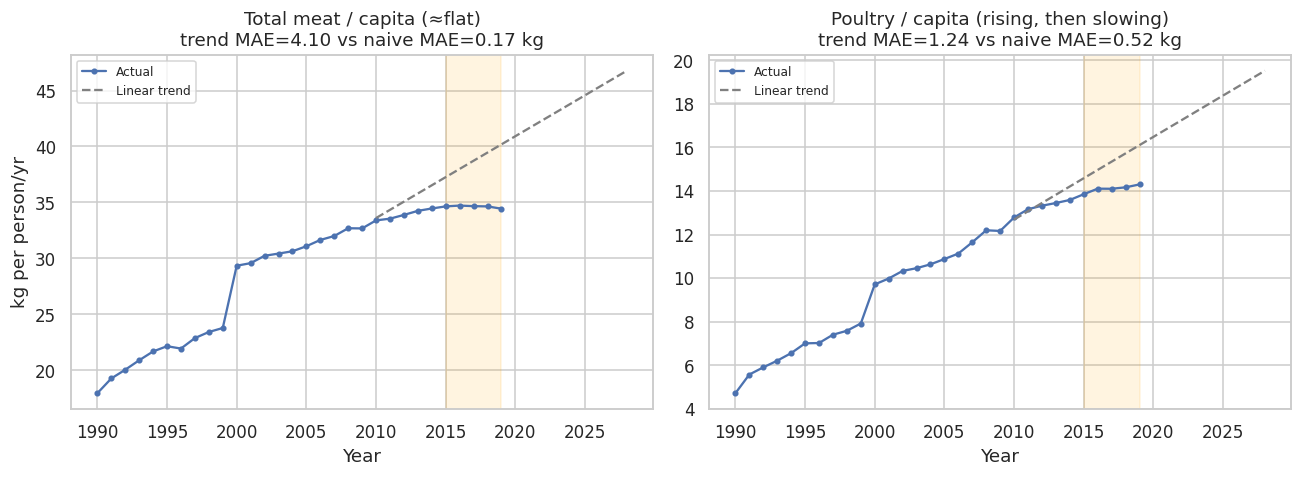

Total meat : trend 4.10 vs naive 0.17  -> naive wins (flat series)
Poultry    : trend 1.24 vs naive 0.52  -> naive wins too (growth slowed; trend overshoots)


In [8]:
def validate(col, ax, title):
    s = kcap[kcap.LOCATION=="WLD"].copy()
    s["val"] = s[col] if col in TYPES else s[TYPES].sum(axis=1)
    h = s[s.TIME<=2019]; tr = h[h.TIME<=2014]; te = h[h.TIME>=2015]
    lr = LinearRegression().fit(tr[["TIME"]], tr["val"]); pr = lr.predict(te[["TIME"]])
    base = np.repeat(tr["val"].iloc[-1], len(te))
    mae_lr = mean_absolute_error(te["val"], pr); mae_b = mean_absolute_error(te["val"], base)
    fut = pd.DataFrame({"TIME": range(2010,2029)})
    ax.plot(h.TIME, h.val, "o-", ms=3, label="Actual")
    ax.plot(fut.TIME, lr.predict(fut[["TIME"]]), "--", color="grey", label="Linear trend")
    ax.axvspan(2015,2019, color="orange", alpha=.12)
    ax.set_title(f"{title}\ntrend MAE={mae_lr:.2f} vs naive MAE={mae_b:.2f} kg"); ax.set_xlabel("Year"); ax.legend(fontsize=8)
    return mae_lr, mae_b

fig,(a1,a2) = plt.subplots(1,2, figsize=(12,4.5))
t_lr,t_b = validate("TOTAL", a1, "Total meat / capita (≈flat)"); a1.set_ylabel("kg per person/yr")
p_lr,p_b = validate("POULTRY", a2, "Poultry / capita (rising, then slowing)")
plt.tight_layout(); plt.savefig("figures/05_forecast.png"); plt.show()
print(f"Total meat : trend {t_lr:.2f} vs naive {t_b:.2f}  -> naive wins (flat series)")
print(f"Poultry    : trend {p_lr:.2f} vs naive {p_b:.2f}  -> naive wins too (growth slowed; trend overshoots)")

**Reading this:** for smooth aggregate series over a 5-year horizon, the naive baseline is hard to beat, and a linear trend *overshoots* once growth flattens (clearly visible above). The point of a forecasting step isn't to declare a winner — it's to establish whether a model genuinely adds value. Here it doesn't, and saying so plainly is the rigorous answer.

## 5. A practical lever: shifting beef to poultry
Because beef is so much more carbon-intense, modest substitution toward poultry yields outsized emissions savings — a concrete, *actionable* supply-chain insight.

In [9]:
b = latest["BEEF"]; shift = 0.25*b; base_co2 = latest.total_co2_Mt
new_co2 = base_co2 - shift*EF["BEEF"]*1e-3 + shift*EF["POULTRY"]*1e-3
print(f"World 2020 meat footprint: {base_co2:.0f} Mt CO2e")
print(f"If 25% of beef volume shifts to poultry: {new_co2:.0f} Mt CO2e  ->  {(base_co2-new_co2)/base_co2*100:.1f}% reduction")

World 2020 meat footprint: 10464 Mt CO2e
If 25% of beef volume shifts to poultry: 8862 Mt CO2e  ->  15.3% reduction


## 6. Independent cross-check (multi-source)
Do countries whose *diets* are more carbon-intense also show higher *national methane* (an agriculture-heavy gas)? We join the meat-diet metric to OWID methane per capita. We expect a **positive but imperfect** relationship — methane has many sources besides livestock (rice, waste, fossil fuels), so this is a sanity check, not an attribution.

corr(meat CO2e/capita, national methane/capita) = 0.41  (n=35)


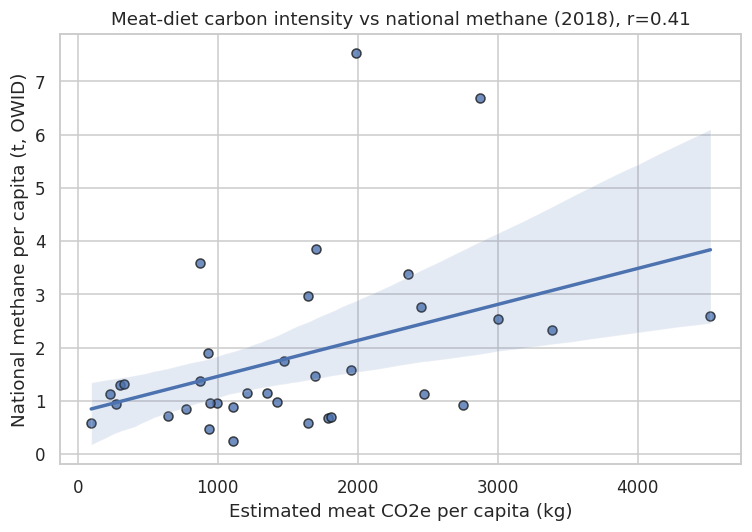

In [10]:
ow = pd.read_csv("data/owid_emissions_subset.csv")
iso = ow[ow.year==2018][["iso_code","methane","population"]].dropna()
mrg = cc.merge(iso, left_on="LOCATION", right_on="iso_code", how="inner")
mrg["methane_pc"] = mrg["methane"]/mrg["population"]*1e6
r = mrg[["co2_pc","methane_pc"]].corr().iloc[0,1]
print(f"corr(meat CO2e/capita, national methane/capita) = {r:.2f}  (n={len(mrg)})")

plt.figure(figsize=(7,5))
sns.regplot(data=mrg, x="co2_pc", y="methane_pc", scatter_kws={"s":35,"edgecolor":"k"})
plt.xlabel("Estimated meat CO2e per capita (kg)"); plt.ylabel("National methane per capita (t, OWID)")
plt.title(f"Meat-diet carbon intensity vs national methane (2018), r={r:.2f}")
plt.tight_layout(); plt.savefig("figures/06_multisource.png"); plt.show()

## Key findings
1. **Composition beats quantity.** Beef is ~21% of world meat volume but ~68% of its carbon footprint (2020).
2. **The poultry shift is real and helpful.** Per-capita meat is roughly flat; the move toward poultry (≈10× less carbon-intense than beef) lowers average intensity.
3. **Diet archetypes differ ~2×** in carbon per kg of meat (≈27 for poultry-led vs ≈59 for beef/sheep-led mixes).
4. **Models must be benchmarked.** A naive baseline beat a linear trend for these series; honest reporting > a forced "model wins".
5. **A clear lever:** shifting 25% of beef volume to poultry → ~15% lower meat footprint.

## Limitations (and they matter)
- **Emission factors are global means.** Real intensity varies hugely by production system/region — the variation FAI specialises in. Results are first-order comparisons, not inventories.
- **Consumption ≠ production.** Trade means a country's *consumption* footprint differs from what it *produces*; this analysis is demand-side.
- **Aggregates & coverage.** OECD–FAO covers major economies, not every country; aggregate regions were separated out.
- **The methane cross-check is correlational** — methane has many non-livestock sources.

## What I'd do next
- Use **per-country, per-system emission factors** (e.g., GLEAM/IPCC tiers) instead of global means.
- Split **production vs consumption** using trade data for a true supply-chain footprint.
- Add **land use and water** alongside GHG for a fuller sustainability picture.
- Reframe forecasting as **scenario modelling** (demand drivers: income, population, prices) rather than naive extrapolation.

---
*Data: OECD–FAO Agricultural Outlook (meat); Our World in Data (emissions). Emission factors: Poore & Nemecek (2018), Science.*